## Примеры анализа большого числа импульсов

Рекомендуется запускать при настройках `console_level: "ERROR"` и `show_progress: false` в `config.yaml`

При первом запуске выполнение может занять большое время из-за скачивания нескольких сотен импульсов с сервера

Анализируем 300 выстрелов...


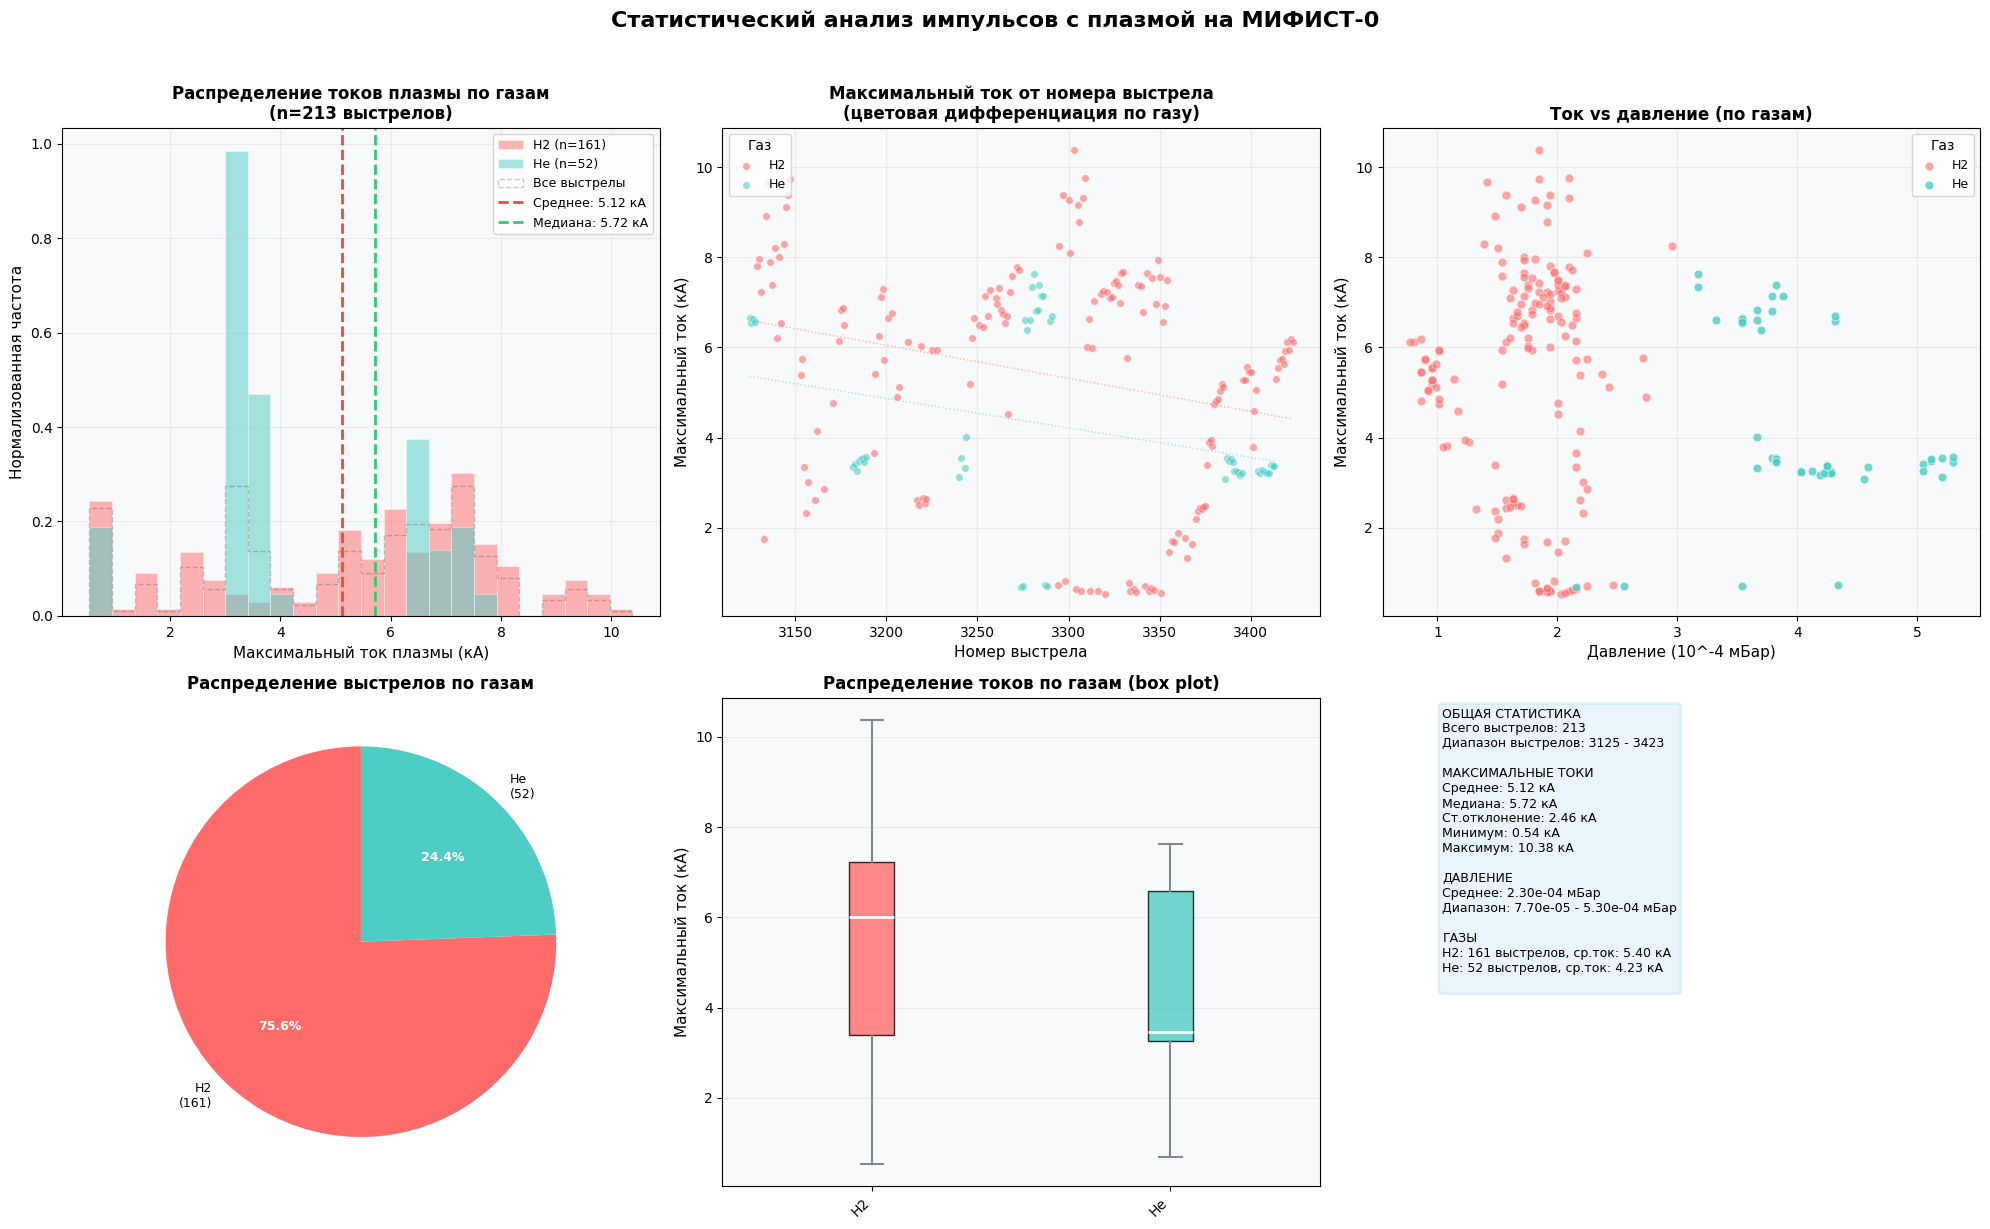

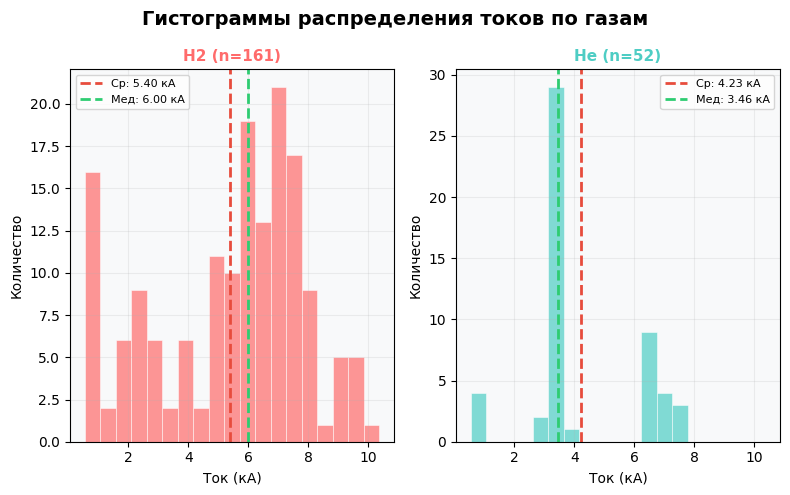

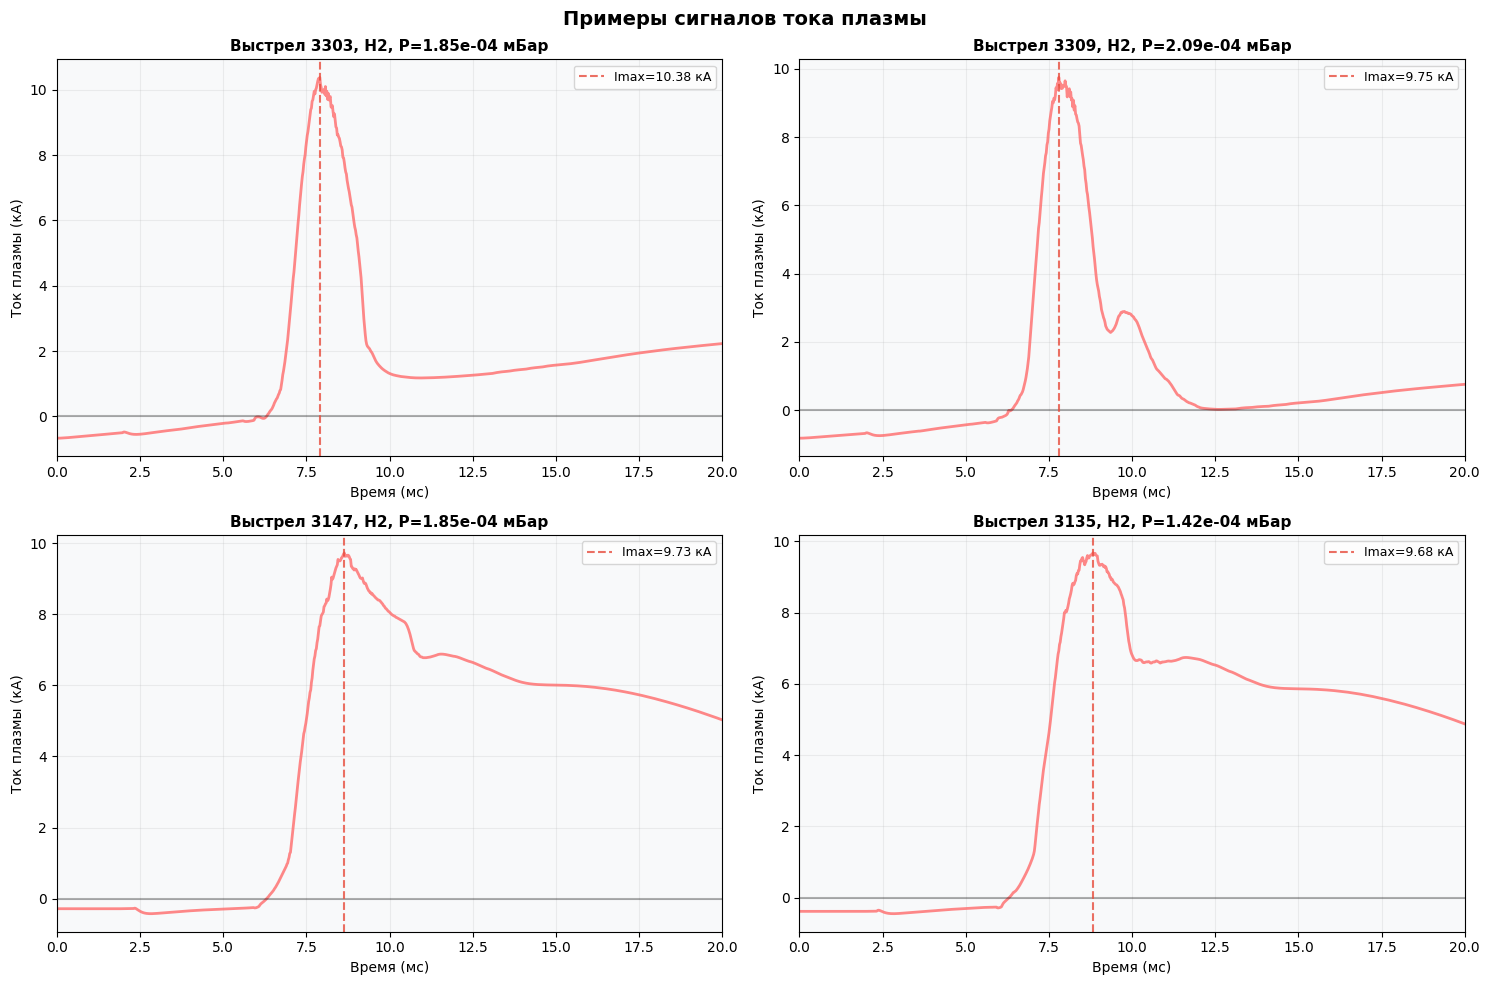

Данные сохранены в shots_analysis.csv

ТОП-10 выстрелов по максимальному току:
 shot_id gas  pressure    Ip_max
    3303  H2  0.000185 10.382189
    3309  H2  0.000209  9.747923
    3147  H2  0.000185  9.728955
    3135  H2  0.000142  9.676597
    3297  H2  0.000194  9.390530
    3146  H2  0.000157  9.375470
    3308  H2  0.000209  9.324828
    3300  H2  0.000182  9.277848
    3305  H2  0.000191  9.154519
    3145  H2  0.000169  9.114570


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Optional, Tuple
import pandas as pd

CONST_SHOTS_TO_PROCESS = 10  #число импульсов, которые будут обработаны, начиная с последних


def safe_interp(new_time, old_time, data, default=0.0):
    """
    Безопасная интерполяция данных на новую временную сетку
    """
    if data is None or len(data) == 0:
        return np.full_like(new_time, default)
    
    unique_indices = np.unique(old_time, return_index=True)[1]
    old_time_unique = old_time[unique_indices]
    data_unique = data[unique_indices]
    
    return np.interp(new_time, old_time_unique, data_unique, left=default, right=default)

def analyze_shots_distribution(client, shot_numbers: List[int], 
                               gas_filter: Optional[str] = None,
                               pressure_range: Optional[Tuple[float, float]] = None):
    """
    Анализирует распределение основных параметров выстрелов.
    
    Args:
        client: Клиент mephistdatakit
        shot_numbers: Список номеров импульсов для анализа
        gas_filter: Фильтр по типу газа (например, 'H2', 'Ar', 'He')
        pressure_range: Диапазон давлений (мин, макс) в мБар
    """

    gas_colors = {
        'H2': '#FF6B6B',   
        'D2': '#FFA726',     
        'He': '#4ECDC4',    
        'Ar': '#6A5ACD',    
        'N2': '#45B7D1',    
        'ArH': '#54A0FF',   
        'H2Ar': '#6A5ACD',  
        'HeAr': '#5F27CD',  
        'Air': '#95A5A6',   
        'VAC': "#000000"
    }
    
    all_data = []
    
    available_shots = client.get_shots_list()
    # Интерполируем всё на общую сетку, чтобы удобнее было выбирать временной диапазон поиска максимума
    Time = np.linspace(0, 21, 1000)

    for shot_number in shot_numbers:
        if shot_number not in available_shots:
            print(f"Импульс {shot_number} отсутствует в базе данных!")
            continue
            
        shot = mdk.Shot(client.get_shot(shot_number))
        
        try:
            shot_id = shot.get_shot_id()
            gas = shot.get_gas()
            pressure = shot.get_pressure()
            time_Ip, Ip = shot.get_plasma_current()
            
            if shot_id is None or gas is None or pressure is None:
                continue
                
            # Применяем фильтры
            if gas_filter and gas in gas_filter:
                continue
                
            if pressure_range and not (pressure_range[0] <= pressure <= pressure_range[1]):
                continue
            
            if Ip is not None and len(Ip) > 0:
                Ip_interp = safe_interp(Time, time_Ip, Ip, 0.0)
                
                # Находим максимум тока в интервале 5-12 мс
                idx_start = int(5/21 * 1000)
                idx_end = int(12/21 * 1000)
                
                if idx_end > len(Ip_interp):
                    idx_end = len(Ip_interp)
                
                Ip_max = np.max(Ip_interp[idx_start:idx_end])
                
                # Фильтруем некорректные значения 
                # значения больше 30 - некорректное вычитания синтетического сигнала
                # значение меньше 500 А - шум.
                if Ip_max < 0 or Ip_max > 30 or Ip_max < 0.5:
                    Ip_max = 0                
                else: # Мы не хотим учитывать в статистике импульсы без плазмы и с некоррктным обсчётом
                    all_data.append({
                        'shot_id': shot_id,
                        'gas': gas,
                        'pressure': pressure,
                        'Ip_max': Ip_max,
                        'time_ms': Time,
                        'Ip': Ip_interp
                    })
                    
        except Exception as e:
            print(f"Ошибка при обработке выстрела {shot_number}: {e}")
            continue
    
    if not all_data:
        print("Нет данных для анализа")
        return None
    
    df = pd.DataFrame(all_data)
    
    # Определяем уникальные газы и их цвета
    gases = sorted(df['gas'].unique())
    
    # Создаем палитру для текущих газов
    current_gas_colors = {}
    for i, gas in enumerate(gases):
        if gas in gas_colors:
            current_gas_colors[gas] = gas_colors[gas]
        else:
            # Используем цвета из таблицы для неизвестных газов
            tab_colors = plt.cm.tab20(np.linspace(0, 1, len(gases)))
            current_gas_colors[gas] = tab_colors[i]
    
    # Строим графики
    fig = plt.figure(figsize=(20, 12))
    
    # 1. Гистограмма распределения максимальных токов
    ax1 = plt.subplot(2, 3, 1)
    if len(df) > 0:
        max_ip = df['Ip_max'].max()
        min_ip = df['Ip_max'].min()
        bins = np.linspace(min_ip, max_ip, 25)
        
        for gas in gases:
            gas_data = df[df['gas'] == gas]
            if len(gas_data) > 0:
                color = current_gas_colors[gas]
                ax1.hist(gas_data['Ip_max'], bins=bins, alpha=0.5, 
                        color=color, edgecolor='white', linewidth=0.5,
                        label=f'{gas} (n={len(gas_data)})', density=True)
        
        ax1.hist(df['Ip_max'], bins=bins, alpha=0.2, color='black', 
                edgecolor='black', linewidth=1, density=True, 
                label='Все выстрелы', histtype='step', linestyle='--')
        
        ax1.axvline(df['Ip_max'].mean(), color='#e74c3c', linestyle='--', 
                   linewidth=2, label=f'Среднее: {df["Ip_max"].mean():.2f} кА')
        ax1.axvline(df['Ip_max'].median(), color='#2ecc71', linestyle='--', 
                   linewidth=2, label=f'Медиана: {df["Ip_max"].median():.2f} кА')
        
        ax1.set_xlabel('Максимальный ток плазмы (кА)', fontsize=11)
        ax1.set_ylabel('Нормализованная частота', fontsize=11)
        ax1.set_title(f'Распределение токов плазмы по газам\n(n={len(df)} выстрелов)', 
                     fontsize=12, fontweight='bold')
        ax1.legend(fontsize=9, loc='upper right')
        ax1.grid(True, alpha=0.2)
        ax1.set_facecolor('#f8f9fa')
    
    # 2. Максимальный ток vs номер выстрела (цвет по газу)
    ax2 = plt.subplot(2, 3, 2)
    
    for gas in gases:
        gas_data = df[df['gas'] == gas]
        if len(gas_data) > 0:
            color = current_gas_colors[gas]
            marker_size = 50 if len(gas_data) < 30 else 30
            alpha = 0.8 if len(gas_data) < 50 else 0.6
            
            ax2.scatter(gas_data['shot_id'], gas_data['Ip_max'], 
                       alpha=alpha, color=color, label=gas,
                       s=marker_size, edgecolors='white', linewidth=0.5)
    
    # Линии тренда для каждого газа
    if len(gases) > 1:
        for gas in gases:
            gas_data = df[df['gas'] == gas]
            if len(gas_data) > 2:  # Нужно минимум 3 точки для тренда
                z = np.polyfit(gas_data['shot_id'], gas_data['Ip_max'], 1)
                p = np.poly1d(z)
                color = current_gas_colors[gas]
                ax2.plot(gas_data['shot_id'], p(gas_data['shot_id']), 
                        color=color, linestyle=':', alpha=0.5, linewidth=1)
    
    ax2.set_xlabel('Номер выстрела', fontsize=11)
    ax2.set_ylabel('Максимальный ток (кА)', fontsize=11)
    ax2.set_title('Максимальный ток от номера выстрела\n(цветовая дифференциация по газу)', 
                 fontsize=12, fontweight='bold')
    ax2.legend(title='Газ', fontsize=9, title_fontsize=10, loc='upper left')
    ax2.grid(True, alpha=0.2)
    ax2.set_facecolor('#f8f9fa')
    
    # 3. Ток vs давление для разных газов
    ax3 = plt.subplot(2, 3, 3)
    
    for gas in gases:
        gas_data = df[df['gas'] == gas]
        if len(gas_data) > 0:
            color = current_gas_colors[gas]
            marker_size = 60 if len(gas_data) < 50 else 40
            alpha = 0.8 if len(gas_data) < 100 else 0.6
            ax3.scatter(gas_data['pressure']*10000, gas_data['Ip_max'], 
                       alpha=alpha, color=color, label=gas, 
                       s=marker_size, edgecolors='white', linewidth=0.5)
    
    ax3.set_xlabel('Давление (10^-4 мБар)', fontsize=11)
    ax3.set_ylabel('Максимальный ток (кА)', fontsize=11)
    ax3.set_title('Ток vs давление (по газам)', fontsize=12, fontweight='bold')
    ax3.legend(title='Газ', fontsize=9, title_fontsize=10)
    ax3.grid(True, alpha=0.2)
    ax3.set_facecolor('#f8f9fa')
    
    # 4. Распределение по газам (pie chart)
    ax4 = plt.subplot(2, 3, 4)
    gas_counts = df['gas'].value_counts()
    
    if len(gas_counts) > 0:
        pie_colors = [current_gas_colors[gas] for gas in gas_counts.index]        
        labels = [f'{gas}\n({count})' for gas, count in zip(gas_counts.index, gas_counts.values)]        
        explode = [0.05 if count < max(gas_counts.values) * 0.3 else 0 
                  for count in gas_counts.values]
        
        wedges, texts, autotexts = ax4.pie(gas_counts.values, 
                                           labels=labels, 
                                           autopct='%1.1f%%',
                                           startangle=90, 
                                           colors=pie_colors,
                                           explode=explode,
                                           textprops={'fontsize': 9})        
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
        
        ax4.set_title('Распределение выстрелов по газам', 
                     fontsize=12, fontweight='bold')
    
    # 5. Статистика по газам (box plot)
    ax5 = plt.subplot(2, 3, 5)
    if len(gases) > 0:
        box_data = [df[df['gas'] == gas]['Ip_max'].values for gas in gases]
        bp = ax5.boxplot(box_data, tick_labels=gases, patch_artist=True,
                        medianprops={'color': 'white', 'linewidth': 2})
        
        for patch, gas in zip(bp['boxes'], gases):
            patch.set_facecolor(current_gas_colors[gas])
            patch.set_alpha(0.8)
        
        for whisker in bp['whiskers']:
            whisker.set(color='#7f8c8d', linewidth=1.5)
        for cap in bp['caps']:
            cap.set(color='#7f8c8d', linewidth=1.5)
        for flier in bp['fliers']:
            flier.set(marker='o', color='#e74c3c', alpha=0.5, markersize=5)
        
        ax5.set_ylabel('Максимальный ток (кА)', fontsize=11)
        ax5.set_title('Распределение токов по газам (box plot)', 
                     fontsize=12, fontweight='bold')
        ax5.grid(True, alpha=0.2, axis='y')
        ax5.set_facecolor('#f8f9fa')
        
        plt.setp(ax5.get_xticklabels(), rotation=45, ha='right', fontsize=10)
    
    # 6. Сводная статистика
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('off')
    
    stats_bg_color = '#3498db' 
    
    stats_text = f"ОБЩАЯ СТАТИСТИКА\n"
    stats_text += f"Всего выстрелов: {len(df)}\n"
    stats_text += f"Диапазон выстрелов: {df['shot_id'].min()} - {df['shot_id'].max()}\n\n"
    
    stats_text += f"МАКСИМАЛЬНЫЕ ТОКИ\n"
    stats_text += f"Среднее: {df['Ip_max'].mean():.2f} кА\n"
    stats_text += f"Медиана: {df['Ip_max'].median():.2f} кА\n"
    stats_text += f"Ст.отклонение: {df['Ip_max'].std():.2f} кА\n"
    stats_text += f"Минимум: {df['Ip_max'].min():.2f} кА\n"
    stats_text += f"Максимум: {df['Ip_max'].max():.2f} кА\n\n"
    
    stats_text += f"ДАВЛЕНИЕ\n"
    stats_text += f"Среднее: {df['pressure'].mean():.2e} мБар\n"
    stats_text += f"Диапазон: {df['pressure'].min():.2e} - {df['pressure'].max():.2e} мБар\n\n"
    
    stats_text += f"ГАЗЫ\n"
    for gas in gases:
        gas_stats = df[df['gas'] == gas]
        stats_text += f"{gas}: {len(gas_stats)} выстрелов, "
        stats_text += f"ср.ток: {gas_stats['Ip_max'].mean():.2f} кА\n"
    
    ax6.text(0.1, 0.98, stats_text, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', 
                     facecolor=stats_bg_color, 
                     alpha=0.1,
                     edgecolor=stats_bg_color,
                     linewidth=2))
    
    fig.suptitle(f'Статистический анализ импульсов с плазмой на МИФИСТ-0', 
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # ДОПОЛНИТЕЛЬНЫЙ ГРАФИК: Раздельные гистограммы для каждого газа
    if len(gases) > 1:
        fig_hist, axes_hist = plt.subplots(1, len(gases), figsize=(4*len(gases), 5))
        if len(gases) == 1:
            axes_hist = [axes_hist]
        
        fig_hist.suptitle('Гистограммы распределения токов по газам', 
                         fontsize=14, fontweight='bold')        
        max_ip = df['Ip_max'].max()
        min_ip = df['Ip_max'].min()
        bins = np.linspace(min_ip, max_ip, 20)
        
        for idx, gas in enumerate(gases):
            if idx < len(axes_hist): 
                ax = axes_hist[idx]
                gas_data = df[df['gas'] == gas]
                
                if len(gas_data) > 0:
                    color = current_gas_colors[gas]
                    ax.hist(gas_data['Ip_max'], bins=bins, alpha=0.7, 
                           color=color, edgecolor='white', linewidth=0.5)
                    
                    mean_val = gas_data['Ip_max'].mean()
                    median_val = gas_data['Ip_max'].median()
                    
                    ax.axvline(mean_val, color='#e74c3c', linestyle='--', 
                              linewidth=2, label=f'Ср: {mean_val:.2f} кА')
                    ax.axvline(median_val, color='#2ecc71', linestyle='--', 
                              linewidth=2, label=f'Мед: {median_val:.2f} кА')
                    
                    ax.set_xlabel('Ток (кА)', fontsize=10)
                    ax.set_ylabel('Количество', fontsize=10)
                    ax.set_title(f'{gas} (n={len(gas_data)})', 
                               fontsize=11, fontweight='bold', color=color)
                    ax.legend(fontsize=8)
                    ax.grid(True, alpha=0.2)
                    ax.set_facecolor('#f8f9fa')
        
        plt.tight_layout()
        plt.show()
    
    # Дополнительные графики - примеры сигналов
    if len(df) > 4:
        fig2, axes2 = plt.subplots(2, 2, figsize=(15, 10))
        fig2.suptitle('Примеры сигналов тока плазмы', fontsize=14, fontweight='bold')
        
        sample_shots = df.nlargest(4, 'Ip_max')  # 4 выстрела с наибольшим током
        
        for idx, (_, row) in enumerate(sample_shots.iterrows()):
            ax = axes2[idx // 2, idx % 2]
            
            shot = mdk.Shot(client.get_shot(int(row['shot_id'])))
            time_Ip, Ip = shot.get_plasma_current()
            
            if len(time_Ip) > 0 and len(Ip) > 0:
                time_ms = time_Ip if time_Ip[-1] > 1 else time_Ip
                gas_color = current_gas_colors.get(row['gas'], '#3498db')
                
                ax.plot(time_ms, Ip, color=gas_color, linewidth=2, alpha=0.8)
                ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
                
                # Находим точку максимального тока
                max_idx = np.argmax(np.abs(row['Ip']))
                ax.axvline(x=row['time_ms'][max_idx] if max_idx < len(row['time_ms']) else 0,
                          color='#e74c3c', linestyle='--', alpha=0.8, linewidth=1.5,
                          label=f'Imax={row["Ip_max"]:.2f} кА')
                
                ax.set_xlabel('Время (мс)', fontsize=10)
                ax.set_ylabel('Ток плазмы (кА)', fontsize=10)
                ax.set_title(f'Выстрел {int(row["shot_id"])}, {row["gas"]}, P={row["pressure"]:.2e} мБар',
                           fontsize=11, fontweight='bold')
                ax.legend(fontsize=9)
                ax.grid(True, alpha=0.2)
                ax.set_xlim(0, 20)
                ax.set_facecolor('#f8f9fa')
        
        plt.tight_layout()
        plt.show()
    
    return df, fig


if __name__ == "__main__":
    import mephistdatakit as mdk
    
    # Создаем клиент
    client = mdk.Client()
    
    # Получаем список доступных выстрелов
    all_shots = client.get_shots_list()
    
    NUMBER_OF_SHOTS = CONST_SHOTS_TO_PROCESS

    
    # Выбираем диапазон выстрелов для анализа 
    if len(all_shots) > NUMBER_OF_SHOTS:
        shot_numbers = sorted(all_shots)[-NUMBER_OF_SHOTS:] 
    else:
        shot_numbers = all_shots
    
    print(f"Анализируем {len(shot_numbers)} выстрелов...")
    
    # Полный анализ
    df, fig = analyze_shots_distribution(
        client, 
        shot_numbers,
        gas_filter={'VAC','H2Ar'},
        pressure_range=None
    )
    
    plt.show()
    
    # Анализ корреляций
    if df is not None:
        # Сохраняем данные в CSV
        df.to_csv('shots_analysis.csv', index=False)
        print(f"Данные сохранены в shots_analysis.csv")
        
        # Дополнительный анализ: топ-10 выстрелов по току
        print("\nТОП-10 выстрелов по максимальному току:")
        top_shots = df.nlargest(10, 'Ip_max')[['shot_id', 'gas', 'pressure', 'Ip_max']]
        print(top_shots.to_string(index=False))